# ***Libraries***

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn import metrics

# decision tree for multioutput regression
from sklearn.tree import DecisionTreeRegressor

# KNN for multioutput regression
from sklearn.neighbors import KNeighborsRegressor

# KNN for multioutput regression
from sklearn.svm import SVR

# ***Data Preprocessing***

In [ ]:
dataset = pd.read_excel("/content/drive/MyDrive/kaj/TMS_Data.xlsx")

In [ ]:
dataset.head(2)

,UserId,TaskHistoryId,ProjectId,ClientId,TypeName,TaskOverallState,PriorityName,TotalWorkingTimeInHour,NoOfStart,NoOfPause,NoOfFinish,DaysRequired,TotalWorkingDay
0,2,3533,8,5,Support,Pause,Medium,82.88,83,83,0,330,71
1,2,176,16,10,Support,Finish,Medium,3.62,11,9,10,328,14


In [ ]:
label_encoder = preprocessing.LabelEncoder()
dataset['TypeName']= label_encoder.fit_transform(dataset['TypeName'])
dataset['TaskOverallState']= label_encoder.fit_transform(dataset['TaskOverallState'])
dataset['PriorityName']= label_encoder.fit_transform(dataset['PriorityName'])

In [ ]:
dataset.head(3)

,UserId,TaskHistoryId,ProjectId,ClientId,TypeName,TaskOverallState,PriorityName,TotalWorkingTimeInHour,NoOfStart,NoOfPause,NoOfFinish,DaysRequired,TotalWorkingDay
0,2,3533,8,5,11,1,3,82.88,83,83,0,330,71
1,2,176,16,10,11,0,3,3.62,11,9,10,328,14
2,2,3382,33,20,3,0,1,2.54,3,3,1,298,3


In [ ]:
#data = pd.DataFrame(dataset, columns=['UserId','ProjectId', 'ClientId', 'TypeName', 'TaskOverallState', 'PriorityName'])

data = pd.DataFrame(dataset, columns=['ProjectId', 'ClientId', 'TypeName', 'TaskOverallState', 'PriorityName'])
Total_label = pd.DataFrame(dataset, columns=['TotalWorkingTimeInHour', 'DaysRequired', 'TotalWorkingDay'])

############################################################################
label1 = pd.DataFrame(dataset, columns=['TotalWorkingTimeInHour'])
label2 = pd.DataFrame(dataset, columns=['DaysRequired'])
label3 = pd.DataFrame(dataset, columns=['TotalWorkingDay'])

# ***Model1_DecisionTreeRegressor***

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(data, label1, test_size = 0.10, random_state = 0)

In [ ]:
#To show individual output TotalWorkingTimeInHour
# define model
model1 = DecisionTreeRegressor()
# fit model
model1.fit(X_Train, Y_Train)

yhat1 = model1.predict(X_Test)
# summarize prediction
print("Predicted_Output, TotalWorkingTimeInHour:", yhat1)

In [ ]:
'''
i = 405
# make a prediction
row = [X_Test['ProjectId'][i], X_Test['ClientId'][i], X_Test['TypeName'][i], X_Test['TaskOverallState'][i],  X_Test['PriorityName'][i]]#Y_Test
print("Input Value:", row)
###################################

yhat = model1.predict([row])

# summarize prediction
print('Predicted_Output, TotalWorkingTimeInHour:', yhat)
Actual = [Y_Test['TotalWorkingTimeInHour'][i]]#Y_Test

#Actual = [Y_Test['TotalWorkingTimeInHour'][i], Y_Test['DaysRequired'][i], Y_Test['TotalWorkingDay'][i]]#Y_Test
print("Actual_Output, TotalWorkingTimeInHour:", Actual)
'''

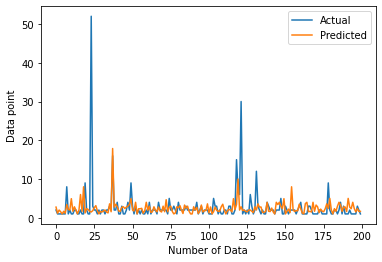

In [ ]:
X_axis_generate = np.arange(0, 200, 1)

plt.plot(X_axis_generate, Y_Test, label = "Actual")

plt.plot(X_axis_generate, yhat1, label = "Predicted")

# naming the x axis
plt.xlabel('Number of Data')
# naming the y axis
plt.ylabel('Data point')

# show a legend on the plot
plt.legend()

# function to show the plot
plt.show()

In [ ]:
# model evaluation for testing set

mae = metrics.mean_absolute_error(Y_Test, yhat1)
mse = metrics.mean_squared_error(Y_Test, yhat1)
r2 = metrics.r2_score(Y_Test, yhat1)

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))

The model performance for testing set
--------------------------------------
MAE is 1.6498425467546494
MSE is 20.5404381740586
R2 score is -0.008089978899202821


# ***Model2_DecisionTreeRegressor***

In [ ]:
# Splitting the dataset into the Training set and Test set DaysRequired
X_Train, X_Test, Y_Train, Y_Test = train_test_split(data, label2, test_size = 0.10, random_state = 0)

In [ ]:
# define model
model2 = DecisionTreeRegressor()
# fit model
model2.fit(X_Train, Y_Train)

yhat2 = model2.predict(X_Test)

# summarize prediction
print("Predicted_Output, DaysRequired", yhat2)

'''
i = 405
# make a prediction
row = [X_Test['ProjectId'][i], X_Test['ClientId'][i], X_Test['TypeName'][i], X_Test['TaskOverallState'][i],  X_Test['PriorityName'][i]]#Y_Test
#print("Input Value:", row)

yhat = model2.predict([row])

# summarize prediction
print("Predicted_Output, DaysRequired", yhat)
'''

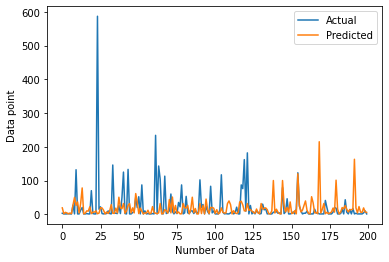

In [ ]:
X_axis_generate = np.arange(0, 200, 1)

plt.plot(X_axis_generate, Y_Test, label = "Actual")

plt.plot(X_axis_generate, yhat2, label = "Predicted")

# naming the x axis
plt.xlabel('Number of Data')
# naming the y axis
plt.ylabel('Data point')



# show a legend on the plot
plt.legend()

# function to show the plot
plt.show()

In [ ]:
# model evaluation for testing set

mae = metrics.mean_absolute_error(Y_Test, yhat2)
mse = metrics.mean_squared_error(Y_Test, yhat2)
r2 = metrics.r2_score(Y_Test, yhat2)

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))

The model performance for testing set
--------------------------------------
MAE is 25.207617468904537
MSE is 3545.29294215488
R2 score is -0.18062544339474673


# ***Model3_DecisionTreeRegressor***

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(data, label3, test_size = 0.10, random_state = 0)

In [ ]:
# define model
model3 = DecisionTreeRegressor()
# fit model
model3.fit(X_Train, Y_Train)
yhat3 = model3.predict(X_Test)

# summarize prediction
print("Predicted_Output, TotalWorkingDay:", yhat3)

'''
i = 405
# make a prediction
row = [X_Test['ProjectId'][i], X_Test['ClientId'][i], X_Test['TypeName'][i], X_Test['TaskOverallState'][i],  X_Test['PriorityName'][i]]#Y_Test
#print("Input Value:", row)
###################################

print('TotalWorkingDay')

yhat3 = model3.predict([row])

# summarize prediction
print("Predicted_Output, TotalWorkingDay:", yhat3)
'''

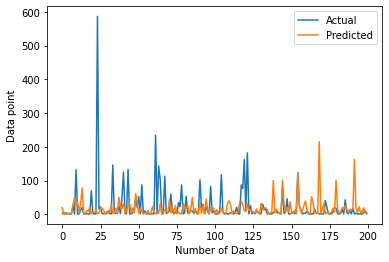

In [ ]:
X_axis_generate = np.arange(0, 200, 1)

plt.plot(X_axis_generate, Y_Test, label = "Actual")

plt.plot(X_axis_generate, yhat3, label = "Predicted")

# naming the x axis
plt.xlabel('Number of Data')
# naming the y axis
plt.ylabel('Data point')



# show a legend on the plot
plt.legend()

# function to show the plot
plt.show()

In [ ]:
# model evaluation for testing set

mae = metrics.mean_absolute_error(Y_Test, yhat3)
mse = metrics.mean_squared_error(Y_Test, yhat3)
r2 = metrics.r2_score(Y_Test, yhat3)

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))

The model performance for testing set
--------------------------------------
MAE is 25.042617468904538
MSE is 3536.5479421548803
R2 score is -0.17771325259106896


# ***Model4_KNeighborsRegressor***

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(data, label1, test_size = 0.10, random_state = 0)

In [ ]:
#To show individual output TotalWorkingTimeInHour
# define model
model4 = KNeighborsRegressor()
# fit model
model4.fit(X_Train, Y_Train)

yhat4 = model4.predict(X_Test)

# summarize prediction
print("Predicted_Output, TotalWorkingTimeInHour:", yhat4)

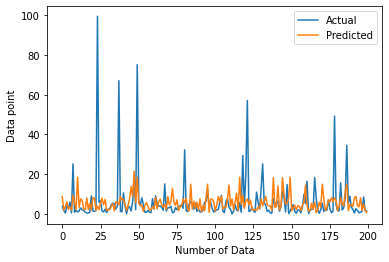

In [ ]:
X_axis_generate = np.arange(0, 200, 1)

plt.plot(X_axis_generate, Y_Test, label = "Actual")

plt.plot(X_axis_generate, yhat4, label = "Predicted")

# naming the x axis
plt.xlabel('Number of Data')
# naming the y axis
plt.ylabel('Data point')

# show a legend on the plot
plt.legend()

# function to show the plot
plt.show()

In [ ]:
# model evaluation for testing set

mae = metrics.mean_absolute_error(Y_Test, yhat4)
mse = metrics.mean_squared_error(Y_Test, yhat4)
r2 = metrics.r2_score(Y_Test, yhat4)

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))

The model performance for testing set
--------------------------------------
MAE is 5.42921
MSE is 135.39421778
R2 score is 0.0339378782611609


# ***Model5_KNeighborsRegressor***

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(data, label2, test_size = 0.10, random_state = 0)

In [ ]:
#To show individual output TotalWorkingTimeInHour
# define model
model5 = KNeighborsRegressor()
# fit model
model5.fit(X_Train, Y_Train)

yhat5 = model5.predict(X_Test)

# summarize prediction
print("Predicted_Output, TotalWorkingTimeInHour:", yhat5)

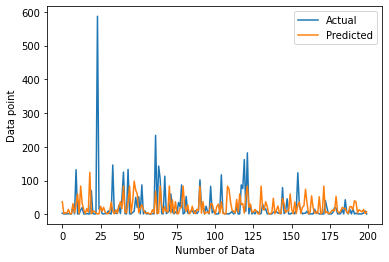

In [ ]:
X_axis_generate = np.arange(0, 200, 1)

plt.plot(X_axis_generate, Y_Test, label = "Actual")

plt.plot(X_axis_generate, yhat5, label = "Predicted")

# naming the x axis
plt.xlabel('Number of Data')
# naming the y axis
plt.ylabel('Data point')

# show a legend on the plot
plt.legend()

# function to show the plot
plt.show()

In [ ]:
# model evaluation for testing set

mae = metrics.mean_absolute_error(Y_Test, yhat5)
mse = metrics.mean_squared_error(Y_Test, yhat5)
r2 = metrics.r2_score(Y_Test, yhat5)

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))

The model performance for testing set
--------------------------------------
MAE is 26.636999999999997
MSE is 3266.9489999999996
R2 score is -0.08793354303993217


# ***Model6_KNeighborsRegressor***

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(data, label3, test_size = 0.10, random_state = 0)

In [ ]:
#To show individual output TotalWorkingTimeInHour
# define model
model6 = KNeighborsRegressor()
# fit model
model6.fit(X_Train, Y_Train)

yhat6 = model6.predict(X_Test)

# summarize prediction
print("Predicted_Output, TotalWorkingTimeInHour:", yhat6)

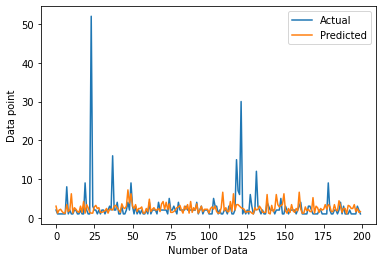

In [ ]:
X_axis_generate = np.arange(0, 200, 1)

plt.plot(X_axis_generate, Y_Test, label = "Actual")

plt.plot(X_axis_generate, yhat6, label = "Predicted")

# naming the x axis
plt.xlabel('Number of Data')
# naming the y axis
plt.ylabel('Data point')

# show a legend on the plot
plt.legend()

# function to show the plot
plt.show()

In [ ]:
# model evaluation for testing set

mae = metrics.mean_absolute_error(Y_Test, yhat6)
mse = metrics.mean_squared_error(Y_Test, yhat6)
r2 = metrics.r2_score(Y_Test, yhat6)

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))

The model performance for testing set
--------------------------------------
MAE is 1.7039999999999997
MSE is 21.537599999999998
R2 score is -0.057028995465163934


# ***Model7_SVMRegressor***

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(data, label1, test_size = 0.10, random_state = 0)

In [ ]:
#To show individual output TotalWorkingTimeInHour
# define model
model7 = SVR(epsilon=0.2)
# fit model
model7.fit(X_Train, Y_Train)

yhat7 = model7.predict(X_Test)

# summarize prediction
print("Predicted_Output, TotalWorkingTimeInHour:", yhat7)

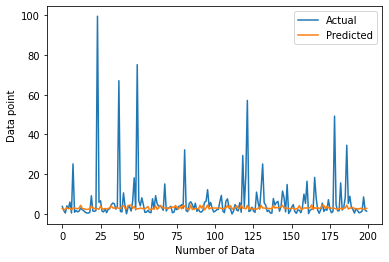

In [ ]:
X_axis_generate = np.arange(0, 200, 1)

plt.plot(X_axis_generate, Y_Test, label = "Actual")

plt.plot(X_axis_generate, yhat7, label = "Predicted")

# naming the x axis
plt.xlabel('Number of Data')
# naming the y axis
plt.ylabel('Data point')

# show a legend on the plot
plt.legend()

# function to show the plot
plt.show()

In [ ]:
# model evaluation for testing set

mae = metrics.mean_absolute_error(Y_Test, yhat7)
mse = metrics.mean_squared_error(Y_Test, yhat7)
r2 = metrics.r2_score(Y_Test, yhat7)

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))

The model performance for testing set
--------------------------------------
MAE is 4.637882892685672
MSE is 148.44545341647515
R2 score is -0.05918503789448892


# ***Model8_SVMRegressor***

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(data, label2, test_size = 0.10, random_state = 0)

In [ ]:
#To show individual output TotalWorkingTimeInHour
# define model
model8 = SVR(epsilon=0.2)
# fit model
model8.fit(X_Train, Y_Train)

yhat8 = model8.predict(X_Test)

# summarize prediction
print("Predicted_Output, TotalWorkingTimeInHour:", yhat8)

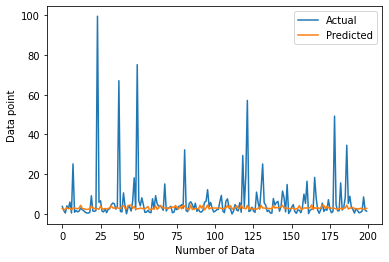

In [ ]:
X_axis_generate = np.arange(0, 200, 1)

plt.plot(X_axis_generate, Y_Test, label = "Actual")

plt.plot(X_axis_generate, yhat8, label = "Predicted")

# naming the x axis
plt.xlabel('Number of Data')
# naming the y axis
plt.ylabel('Data point')

# show a legend on the plot
plt.legend()

# function to show the plot
plt.show()

In [ ]:
# model evaluation for testing set

mae = metrics.mean_absolute_error(Y_Test, yhat8)
mse = metrics.mean_squared_error(Y_Test, yhat8)
r2 = metrics.r2_score(Y_Test, yhat8)

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))

The model performance for testing set
--------------------------------------
MAE is 4.637882892685672
MSE is 148.44545341647515
R2 score is -0.05918503789448892


# ***Model9_SVMRegressor***

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(data, label3, test_size = 0.10, random_state = 0)

In [ ]:
# define model
model9 = SVR(epsilon=0.2)
# fit model
model9.fit(X_Train, Y_Train)

yhat9 = model9.predict(X_Test)

# summarize prediction
print("Predicted_Output, TotalWorkingTimeInHour:", yhat9)

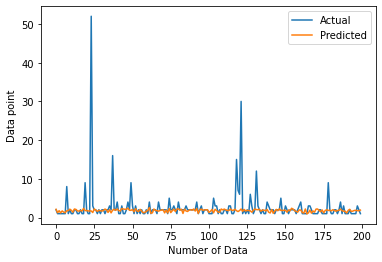

In [ ]:
X_axis_generate = np.arange(0, 200, 1)

plt.plot(X_axis_generate, Y_Test, label = "Actual")

plt.plot(X_axis_generate, yhat9, label = "Predicted")


# naming the x axis
plt.xlabel('Number of Data')
# naming the y axis
plt.ylabel('Data point')

# show a legend on the plot
plt.legend()

# function to show the plot
plt.show()

In [ ]:
# model evaluation for testing set

mae = metrics.mean_absolute_error(Y_Test, yhat9)
mse = metrics.mean_squared_error(Y_Test, yhat9)
r2 = metrics.r2_score(Y_Test, yhat9)

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))

The model performance for testing set
--------------------------------------
MAE is 1.4165955163927257
MSE is 20.922114002809522
R2 score is -0.026821983294210705
